
# 1D partical in a double well example

This notebook reproduces the one-dimensional double-well demonstration used in the paper. It:

1. Defines an asymmetric double-well potential and harmonic approximations around its minima.
2. Constructs a smooth forward protocol
  
   $U_L \rightarrow U_{\rm DW} \rightarrow U_R$
   
   with initial and final equilibration plateaus.
3. Constructs the time-reversed protocol.
4. Simulates overdamped Langevin trajectories.
5. Estimates the instantaneous entropy-production rate from short-time trajectory increments using a polynomial basis.
6. Computes work along each trajectory.

The notebook is self-contained and requires only NumPy and Matplotlib.



## 1. Imports and plotting defaults


In [1]:

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)
plt.rcParams.update({
    "figure.figsize": (8, 4),
    "axes.grid": True,
    "figure.dpi": 120,
})



## 2. Simulation parameters

The overdamped Langevin equation is

$dx_t=-\mu\,\partial_x U(x_t,t)\,dt+\sqrt{2D}\,dW_t,$

with Einstein relation \(D=\mu k_{\mathrm B}T\).

The protocol contains:

- an initial equilibration plateau of duration $t_{eq1}$,
- a finite-time transformation of duration $t_{trans}$,
- a final equilibration plateau of duration $t_{eq2}$.

The parameters are chosen by trial and error to have high entropy production values.


In [2]:

# Ensemble size
N = 10_000

# Double-well asymmetry and horizontal scale
a = -1.0
xscale = 1.0

# Protocol durations
teq1 = 0.9
ttrans = 1.2
teq2 = 0.9

# Integration timestep
dt = 1e-3

# Diffusion coefficient and mobility
D = 0.05
mu = 1.0

# Random seeds for independent forward and reverse ensembles
seed_forward = 0
seed_reverse = 1


## 3. Parameter validation

In [3]:

def validate_parameters(
    xscale=1.0,
    mu=1.0,
    D=0.05,
    dt=1e-3,
    teq1=0.3,
    ttrans=0.4,
    teq2=0.3,
):
    """Validate physical and numerical parameters."""
    if xscale <= 0.0:
        raise ValueError("xscale must be positive.")
    if mu <= 0.0:
        raise ValueError("mu must be positive.")
    if D <= 0.0:
        raise ValueError("D must be positive.")
    if dt <= 0.0:
        raise ValueError("dt must be positive.")
    if teq1 < 0.0 or teq2 < 0.0:
        raise ValueError("Equilibration times must be nonnegative.")
    if ttrans <= 0.0:
        raise ValueError("ttrans must be positive.")


validate_parameters(
    xscale=xscale,
    mu=mu,
    D=D,
    dt=dt,
    teq1=teq1,
    ttrans=ttrans,
    teq2=teq2,
)
print("Parameter validation passed.")


Parameter validation passed.



## 4. Static potentials and their derivatives

The asymmetric double-well potential is

$U_{\rm DW}(x)=\left[\left(\frac{x}{x_{\rm scale}}\right)^2-1\right]^2
+a\left(\frac{x}{x_{\rm scale}}\right)^3.$


The two nonzero stationary points are the left and right minima. Harmonic approximations around these minima define the initial and final equilibrium potentials.


In [4]:

def U_doublewell(x, a=-1.0, xscale=1.0):
    """Asymmetric double-well potential."""
    y = np.asarray(x) / xscale
    return (y**2 - 1.0)**2 + a * y**3


def dUdx_doublewell(x, a=-1.0, xscale=1.0):
    """First spatial derivative of the double-well potential."""
    y = np.asarray(x) / xscale
    return (4.0 * y * (y**2 - 1.0) + 3.0 * a * y**2) / xscale


def d2Udx2_doublewell(x, a=-1.0, xscale=1.0):
    """Second spatial derivative of the double-well potential."""
    y = np.asarray(x) / xscale
    return (12.0 * y**2 - 4.0 + 6.0 * a * y) / xscale**2


def find_minima(a=-1.0, xscale=1.0):
    """Return the left and right minima analytically."""
    if xscale <= 0.0:
        raise ValueError("xscale must be positive.")

    discriminant = np.sqrt(9.0 * a**2 + 64.0)
    y1 = (-3.0 * a - discriminant) / 8.0
    y2 = (-3.0 * a + discriminant) / 8.0

    stationary_points = xscale * np.array([y1, y2])
    stationary_points.sort()

    curvatures = d2Udx2_doublewell(
        stationary_points,
        a=a,
        xscale=xscale,
    )

    if np.any(curvatures <= 0.0):
        raise ValueError(
            "Expected both nonzero stationary points to be minima, "
            f"but obtained curvatures {curvatures}."
        )

    return stationary_points[0], stationary_points[1]


def prepare_potential(a=-1.0, xscale=1.0):
    """Precompute all time-independent potential parameters."""
    xL, xR = find_minima(a=a, xscale=xscale)

    UL0 = U_doublewell(xL, a=a, xscale=xscale)
    UR0 = U_doublewell(xR, a=a, xscale=xscale)

    kL = d2Udx2_doublewell(xL, a=a, xscale=xscale)
    kR = d2Udx2_doublewell(xR, a=a, xscale=xscale)

    if kL <= 0.0 or kR <= 0.0:
        raise ValueError(f"Invalid harmonic curvature: kL={kL}, kR={kR}.")

    return {
        "a": a,
        "xscale": xscale,
        "xL": float(xL),
        "xR": float(xR),
        "UL0": float(UL0),
        "UR0": float(UR0),
        "kL": float(kL),
        "kR": float(kR),
    }


def U_harmonic_from_min(x, x0, a=-1.0, xscale=1.0):
    """Harmonic approximation around minimum x0."""
    U0 = U_doublewell(x0, a=a, xscale=xscale)
    k = d2Udx2_doublewell(x0, a=a, xscale=xscale)

    if k <= 0.0:
        raise ValueError(f"x0={x0} is not a minimum because k={k}.")

    return U0 + 0.5 * k * (np.asarray(x) - x0)**2


def dUdx_harmonic_from_min(x, x0, a=-1.0, xscale=1.0):
    """Derivative of the harmonic approximation around x0."""
    k = d2Udx2_doublewell(x0, a=a, xscale=xscale)

    if k <= 0.0:
        raise ValueError(f"x0={x0} is not a minimum because k={k}.")

    return k * (np.asarray(x) - x0)



## 5. Harmonic free-energy difference

For a one-dimensional harmonic well with minimum energy $U_0$ and curvature $k$, the configurational free energy is $\frac{1}{2}k_{\mathrm B}T\ln k + U_0$. Therefore,

$\Delta F = F_R-F_L
=U_R-U_L+\frac{k_{\mathrm B}T}{2}\ln\!\left(\frac{k_R}{k_L}\right).$



In [5]:

def compute_free_energy_difference(a=-1.0, xscale=1.0, mu=1.0, D=0.05):
    """Harmonic free-energy difference F_R - F_L."""
    validate_parameters(xscale=xscale, mu=mu, D=D)

    potential = prepare_potential(a=a, xscale=xscale)
    kBT = D / mu

    DeltaF = (
        potential["UR0"] - potential["UL0"]
        + 0.5 * kBT * np.log(potential["kR"] / potential["kL"])
    )

    return {
        **potential,
        "separation": potential["xR"] - potential["xL"],
        "kBT": kBT,
        "DeltaF": DeltaF,
        "DeltaF_kBT": DeltaF / kBT,
    }


result = compute_free_energy_difference(
    a=a,
    xscale=xscale,
    mu=mu,
    D=D,
)

for key in ["xL", "xR", "separation", "UL0", "UR0", "kL", "kR", "kBT", "DeltaF", "DeltaF_kBT"]:
    print(f"{key:>12s} = {result[key]:.6f}")


          xL = -0.693000
          xR = 1.443000
  separation = 2.136001
         UL0 = 0.602954
         UR0 = -1.833422
          kL = 5.920999
          kR = 12.329001
         kBT = 0.050000
      DeltaF = -2.418040
  DeltaF_kBT = -48.360797


## 6. Inspect the potential

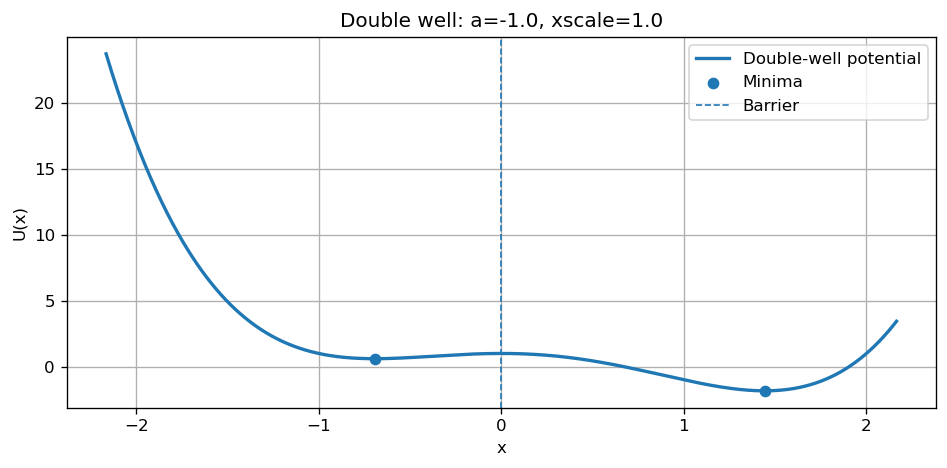

In [6]:

def plot_potential(a=-1.0, xscale=1.0):
    """Plot the double well and mark its two minima."""
    potential = prepare_potential(a=a, xscale=xscale)

    xL = potential["xL"]
    xR = potential["xR"]

    margin = 1.5 * max(abs(xL), abs(xR), xscale)
    x_grid = np.linspace(-margin, margin, 1000)
    U_grid = U_doublewell(x_grid, a=a, xscale=xscale)

    plt.figure()
    plt.plot(x_grid, U_grid, linewidth=2, label="Double-well potential")
    plt.scatter(
        [xL, xR],
        [potential["UL0"], potential["UR0"]],
        zorder=3,
        label="Minima",
    )
    plt.axvline(0.0, linestyle="--", linewidth=1, label="Barrier")
    plt.xlabel("x")
    plt.ylabel("U(x)")
    plt.title(f"Double well: a={a}, xscale={xscale}")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_potential(a=a, xscale=xscale)



## 7. Smooth interpolation protocol

A cubic smoothstep,

$s(u)=u^2(3-2u),$

is used to make the interpolation weights and their first derivatives continuous.

The forward protocol is:

1. left harmonic plateau,
2. smooth interpolation from the left harmonic potential to the double well,
3. smooth interpolation from the double well to the right harmonic potential,
4. right harmonic plateau.


In [7]:

def smoothstep(u):
    """Cubic smoothstep on [0, 1]."""
    u = np.clip(u, 0.0, 1.0)
    return u**2 * (3.0 - 2.0 * u)


def smoothstep_prime(u):
    """Derivative of cubic smoothstep; zero outside [0, 1]."""
    u_array = np.asarray(u, dtype=float)
    result = np.zeros_like(u_array)

    mask = (u_array >= 0.0) & (u_array <= 1.0)
    result[mask] = 6.0 * u_array[mask] * (1.0 - u_array[mask])

    if np.ndim(u) == 0:
        return float(result)
    return result


def potential_components(x, potential):
    """Return left harmonic, double well, and right harmonic energies."""
    x_array = np.asarray(x)

    U_L = potential["UL0"] + 0.5 * potential["kL"] * (x_array - potential["xL"])**2
    U_DW = U_doublewell(
        x_array,
        a=potential["a"],
        xscale=potential["xscale"],
    )
    U_R = potential["UR0"] + 0.5 * potential["kR"] * (x_array - potential["xR"])**2

    return U_L, U_DW, U_R


def gradient_components(x, potential):
    """Return the spatial derivatives of all three potential components."""
    x_array = np.asarray(x)

    dU_L = potential["kL"] * (x_array - potential["xL"])
    dU_DW = dUdx_doublewell(
        x_array,
        a=potential["a"],
        xscale=potential["xscale"],
    )
    dU_R = potential["kR"] * (x_array - potential["xR"])

    return dU_L, dU_DW, dU_R


def protocol_weights(t, teq1=0.3, ttrans=0.4):
    """Interpolation weights for the forward protocol."""
    if ttrans <= 0.0:
        raise ValueError("ttrans must be positive.")

    if t <= teq1:
        return 1.0, 0.0, 0.0

    if t >= teq1 + ttrans:
        return 0.0, 0.0, 1.0

    s = (t - teq1) / ttrans

    if s < 0.5:
        q = 2.0 * s
        beta = smoothstep(q)
        return 1.0 - beta, beta, 0.0

    q = 2.0 * s - 1.0
    gamma = smoothstep(q)
    return 0.0, 1.0 - gamma, gamma


def dUdx_time(
    x,
    t,
    a=-1.0,
    xscale=1.0,
    teq1=0.3,
    ttrans=0.4,
    teq2=0.3,
    potential=None,
):
    """Spatial derivative of the forward time-dependent potential."""
    del teq2

    if potential is None:
        potential = prepare_potential(a=a, xscale=xscale)

    dU_L, dU_DW, dU_R = gradient_components(x, potential)
    alpha, beta, gamma = protocol_weights(t=t, teq1=teq1, ttrans=ttrans)

    return alpha * dU_L + beta * dU_DW + gamma * dU_R


def dUdt_time(
    x,
    t,
    a=-1.0,
    xscale=1.0,
    teq1=0.3,
    ttrans=0.4,
    teq2=0.3,
    potential=None,
):
    """Explicit time derivative of the forward potential."""
    del teq2

    if potential is None:
        potential = prepare_potential(a=a, xscale=xscale)

    x_array = np.asarray(x)

    if t <= teq1 or t >= teq1 + ttrans:
        return np.zeros_like(x_array, dtype=float)

    U_L, U_DW, U_R = potential_components(x_array, potential)
    s = (t - teq1) / ttrans

    if s < 0.5:
        q = 2.0 * s
        weight_rate = 2.0 * smoothstep_prime(q) / ttrans
        return weight_rate * (U_DW - U_L)

    q = 2.0 * s - 1.0
    weight_rate = 2.0 * smoothstep_prime(q) / ttrans
    return weight_rate * (U_R - U_DW)


## 8. Time-reversed protocol

In [8]:

def dUdx_time_reverse(
    x,
    t,
    a=-1.0,
    xscale=1.0,
    teq1=0.3,
    ttrans=0.4,
    teq2=0.3,
    potential=None,
):
    """Spatial derivative of the time-reversed protocol."""
    T_total = teq1 + ttrans + teq2
    reverse_time = T_total - t

    return dUdx_time(
        x=x,
        t=reverse_time,
        a=a,
        xscale=xscale,
        teq1=teq1,
        ttrans=ttrans,
        teq2=teq2,
        potential=potential,
    )


def dUdt_time_reverse(
    x,
    t,
    a=-1.0,
    xscale=1.0,
    teq1=0.3,
    ttrans=0.4,
    teq2=0.3,
    potential=None,
):
    """Explicit time derivative of the time-reversed protocol."""
    T_total = teq1 + ttrans + teq2
    reverse_time = T_total - t

    return -dUdt_time(
        x=x,
        t=reverse_time,
        a=a,
        xscale=xscale,
        teq1=teq1,
        ttrans=ttrans,
        teq2=teq2,
        potential=potential,
    )



## 9. Short-time entropy-production-rate estimator

For each short interval, define the displacement $\Delta x$ and midpoint $\bar x$. The estimator uses the four basis currents
$
\Delta x,\qquad
\bar x\,\Delta x,\qquad
\bar x^2\,\Delta x,\qquad
\bar x^3\,\Delta x.
$

If $\boldsymbol{\mu}$ is the sample mean of these features and $\mathbf C$ their covariance matrix, the optimized quadratic variational estimate is

$\widehat{\sigma} = \frac{2}{\Delta t}\, \boldsymbol{\mu}^{\mathsf T} \mathbf C^{-1} \boldsymbol{\mu}.$


A small relative ridge term stabilizes the covariance inversion.


In [9]:

def estimate_entropy_rate(
    x_old,
    x_new,
    dt,
    ridge_relative=1e-10,
):
    """Estimate the short-time entropy-production rate."""
    diffx = x_new - x_old
    midx = 0.5 * (x_old + x_new)

    features = np.column_stack([
        diffx,
        midx * diffx,
        midx**2 * diffx,
        midx**3 * diffx,
    ])

    mean_features = np.mean(features, axis=0)
    covariance = np.atleast_2d(np.cov(features, rowvar=False))

    covariance_scale = np.trace(covariance) / covariance.shape[0]

    if not np.isfinite(covariance_scale) or covariance_scale <= 0.0:
        covariance_scale = 1.0

    covariance_regularized = (
        covariance
        + ridge_relative
        * covariance_scale
        * np.eye(covariance.shape[0])
    )

    try:
        solution = np.linalg.solve(
            covariance_regularized,
            mean_features,
        )
    except np.linalg.LinAlgError:
        solution = np.linalg.pinv(covariance_regularized) @ mean_features

    sigma_rate = 2.0 * mean_features @ solution / dt

    # A small negative value can only result from numerical roundoff.
    return max(float(sigma_rate), 0.0)


## 10. Time grid and overdamped Langevin simulation

In [10]:

def create_time_grid(teq1, ttrans, teq2, requested_dt):
    """Create a uniform grid that includes both endpoints exactly."""
    T_total = teq1 + ttrans + teq2

    number_of_intervals = max(
        1,
        int(np.round(T_total / requested_dt)),
    )

    t_arr = np.linspace(
        0.0,
        T_total,
        number_of_intervals + 1,
    )

    actual_dt = t_arr[1] - t_arr[0]
    return t_arr, actual_dt


def langevin_ensemble(
    N=100,
    a=-1.0,
    xscale=1.0,
    mu=1.0,
    D=0.05,
    dt=1e-3,
    teq1=0.3,
    ttrans=0.4,
    teq2=0.3,
    seed=0,
    reverse=False,
):
    """Simulate an ensemble of overdamped Langevin trajectories."""
    validate_parameters(
        xscale=xscale,
        mu=mu,
        D=D,
        dt=dt,
        teq1=teq1,
        ttrans=ttrans,
        teq2=teq2,
    )

    if N < 2:
        raise ValueError("N must be at least 2 for covariance estimation.")

    rng = np.random.default_rng(seed)
    potential = prepare_potential(a=a, xscale=xscale)
    kBT = D / mu

    if reverse:
        x_start = potential["xR"]
        initial_curvature = potential["kR"]
    else:
        x_start = potential["xL"]
        initial_curvature = potential["kL"]

    sigma_eq = np.sqrt(kBT / initial_curvature)

    t_arr, actual_dt = create_time_grid(
        teq1=teq1,
        ttrans=ttrans,
        teq2=teq2,
        requested_dt=dt,
    )

    number_of_intervals = len(t_arr) - 1
    x = np.empty((N, number_of_intervals + 1), dtype=float)

    # Exact equilibrium distribution of the initial harmonic well.
    x[:, 0] = x_start + sigma_eq * rng.normal(size=N)

    entropy_rate = np.empty(number_of_intervals, dtype=float)
    noise_scale = np.sqrt(2.0 * D * actual_dt)

    for i in range(number_of_intervals):
        current_x = x[:, i]
        current_t = t_arr[i]

        if reverse:
            gradient = dUdx_time_reverse(
                x=current_x,
                t=current_t,
                a=a,
                xscale=xscale,
                teq1=teq1,
                ttrans=ttrans,
                teq2=teq2,
                potential=potential,
            )
        else:
            gradient = dUdx_time(
                x=current_x,
                t=current_t,
                a=a,
                xscale=xscale,
                teq1=teq1,
                ttrans=ttrans,
                teq2=teq2,
                potential=potential,
            )

        force = -gradient

        next_x = (
            current_x
            + mu * force * actual_dt
            + noise_scale * rng.normal(size=N)
        )

        x[:, i + 1] = next_x

        entropy_rate[i] = estimate_entropy_rate(
            x_old=current_x,
            x_new=next_x,
            dt=actual_dt,
        )

    return t_arr, x, entropy_rate



## 11. Work computation

The work performed along a trajectory is

$W(t)=\int_0^t \partial_s U(x_s,s)\,ds.$


The integral is evaluated with midpoint convention.


In [11]:
def compute_cumulative_work(
    t_arr,
    x_trajs,
    a=-1.0,
    xscale=1.0,
    teq1=0.3,
    ttrans=0.4,
    teq2=0.3,
    reverse=False,
):
    """
    Compute cumulative protocol work using a midpoint
    (Stratonovich-consistent) discretization:

        dW = partial_t U(x_t, t) dt.

    For each interval [t_n, t_{n+1}], partial_t U is evaluated at

        x_mid = (x_n + x_{n+1}) / 2,
        t_mid = (t_n + t_{n+1}) / 2.
    """
    t_arr = np.asarray(t_arr, dtype=float)
    x_trajs = np.asarray(x_trajs, dtype=float)

    if t_arr.ndim != 1:
        raise ValueError("t_arr must be one-dimensional.")

    if x_trajs.ndim != 2:
        raise ValueError("x_trajs must be two-dimensional.")

    n_traj, n_times = x_trajs.shape

    if len(t_arr) != n_times:
        raise ValueError(
            "x_trajs and t_arr must contain the same "
            "number of time points."
        )

    time_steps = np.diff(t_arr)

    if np.any(time_steps <= 0.0):
        raise ValueError("t_arr must be strictly increasing.")

    potential = prepare_potential(
        a=a,
        xscale=xscale,
    )

    # Midpoint coordinates and times for every interval.
    x_mid = 0.5 * (
        x_trajs[:, :-1]
        + x_trajs[:, 1:]
    )

    t_mid = 0.5 * (
        t_arr[:-1]
        + t_arr[1:]
    )

    # One value of partial_t U for every trajectory and interval.
    dUdt_mid = np.empty(
        (n_traj, n_times - 1),
        dtype=float,
    )

    for n, t in enumerate(t_mid):
        if reverse:
            dUdt_mid[:, n] = dUdt_time_reverse(
                x=x_mid[:, n],
                t=t,
                a=a,
                xscale=xscale,
                teq1=teq1,
                ttrans=ttrans,
                teq2=teq2,
                potential=potential,
            )
        else:
            dUdt_mid[:, n] = dUdt_time(
                x=x_mid[:, n],
                t=t,
                a=a,
                xscale=xscale,
                teq1=teq1,
                ttrans=ttrans,
                teq2=teq2,
                potential=potential,
            )

    work_increments = dUdt_mid * time_steps[None, :]

    cumulative_work = np.zeros(
        (n_traj, n_times),
        dtype=float,
    )

    cumulative_work[:, 1:] = np.cumsum(
        work_increments,
        axis=1,
    )

    final_work = cumulative_work[:, -1]

    return cumulative_work, dUdt_mid, final_work

## 12. Numerical stability check

In [12]:

maximum_curvature = max(result["kL"], result["kR"])
relaxation_step = mu * maximum_curvature * dt

print(f"mu * max(kL, kR) * requested_dt = {relaxation_step:.6f}")

if relaxation_step > 0.1:
    print(
        "Warning: the Euler timestep may be large relative to the "
        "stiffest harmonic relaxation time. Consider reducing dt."
    )
else:
    print("The requested timestep passes the conservative stability check.")


mu * max(kL, kR) * requested_dt = 0.012329
The requested timestep passes the conservative stability check.


## 13. Run the forward and reverse simulations

In [13]:

print("Running forward protocol...")
t_arr, x_fwd, sig_f = langevin_ensemble(
    N=N,
    a=a,
    xscale=xscale,
    mu=mu,
    D=D,
    dt=dt,
    teq1=teq1,
    ttrans=ttrans,
    teq2=teq2,
    seed=seed_forward,
    reverse=False,
)

W_cum_fwd, dUdt_fwd, W_fwd = compute_cumulative_work(
    t_arr=t_arr,
    x_trajs=x_fwd,
    a=a,
    xscale=xscale,
    teq1=teq1,
    ttrans=ttrans,
    teq2=teq2,
    reverse=False,
)

print("Running reverse protocol...")
t_arr_rev, x_rev, sig_r = langevin_ensemble(
    N=N,
    a=a,
    xscale=xscale,
    mu=mu,
    D=D,
    dt=dt,
    teq1=teq1,
    ttrans=ttrans,
    teq2=teq2,
    seed=seed_reverse,
    reverse=True,
)

W_cum_rev, dUdt_rev, W_rev = compute_cumulative_work(
    t_arr=t_arr_rev,
    x_trajs=x_rev,
    a=a,
    xscale=xscale,
    teq1=teq1,
    ttrans=ttrans,
    teq2=teq2,
    reverse=True,
)

actual_dt = t_arr[1] - t_arr[0]

print(f"Actual simulation timestep: {actual_dt:.12g}")
print(f"Forward trajectory array: {x_fwd.shape}")
print(f"Reverse trajectory array: {x_rev.shape}")


Running forward protocol...
Running reverse protocol...
Actual simulation timestep: 0.001
Forward trajectory array: (10000, 3001)
Reverse trajectory array: (10000, 3001)


## 14. Plot representative trajectories

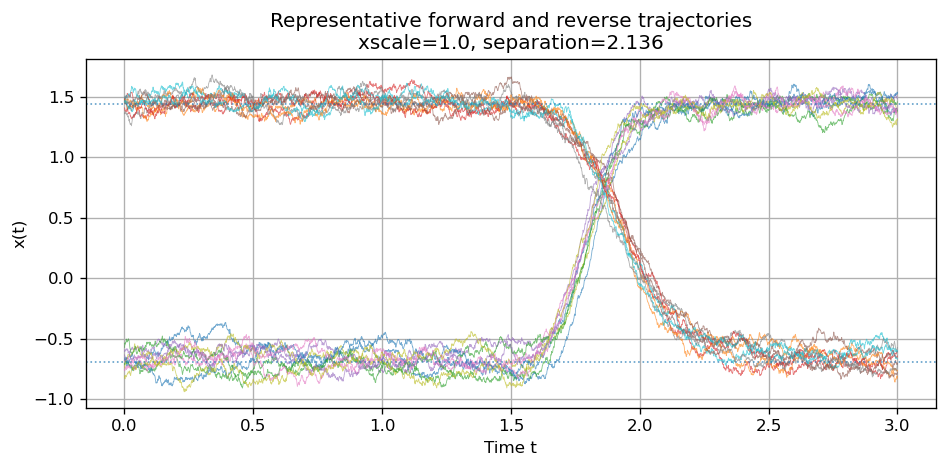

In [14]:

plt.figure()

number_to_plot = min(10, N)

for i in range(number_to_plot):
    plt.plot(t_arr, x_fwd[i], linewidth=0.5, alpha=0.6)
    plt.plot(t_arr_rev, x_rev[i], linewidth=0.5, alpha=0.6)

plt.axhline(result["xL"], linestyle=":", linewidth=1, alpha=0.7)
plt.axhline(result["xR"], linestyle=":", linewidth=1, alpha=0.7)

plt.xlabel("Time t")
plt.ylabel("x(t)")
plt.title(
    "Representative forward and reverse trajectories\n"
    f"xscale={xscale}, separation={result['separation']:.3f}"
)
plt.tight_layout()
plt.show()


## 15. Cumulative work and entropy production

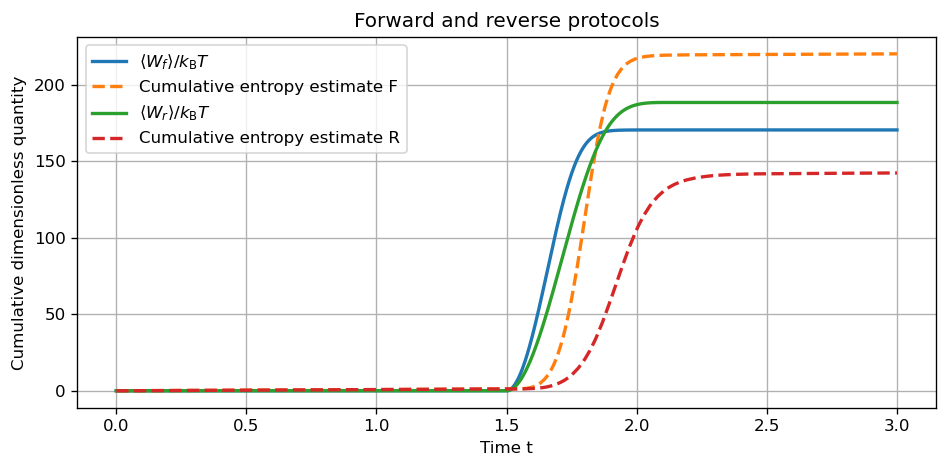

In [15]:

kBT = result["kBT"]

W_mean_fwd = np.mean(W_cum_fwd, axis=0) / kBT
W_mean_rev = np.mean(W_cum_rev, axis=0) / kBT

cumulative_sig_f = np.concatenate([
    [0.0],
    np.cumsum(sig_f * actual_dt),
])

cumulative_sig_r = np.concatenate([
    [0.0],
    np.cumsum(sig_r * actual_dt),
])

plt.figure()
plt.plot(
    t_arr,
    W_mean_fwd,
    linewidth=2,
    label=r"$\langle W_f\rangle/k_{\rm B}T$",
)
plt.plot(
    t_arr,
    cumulative_sig_f,
    "--",
    linewidth=2,
    label="Cumulative entropy estimate F",
)
plt.plot(
    t_arr_rev,
    W_mean_rev,
    linewidth=2,
    label=r"$\langle W_r\rangle/k_{\rm B}T$",
)
plt.plot(
    t_arr_rev,
    cumulative_sig_r,
    "--",
    linewidth=2,
    label="Cumulative entropy estimate R",
)

plt.xlabel("Time t")
plt.ylabel("Cumulative dimensionless quantity")
plt.legend()
plt.title("Forward and reverse protocols")
plt.tight_layout()
plt.show()


## 16. Work distributions and free-energy markers

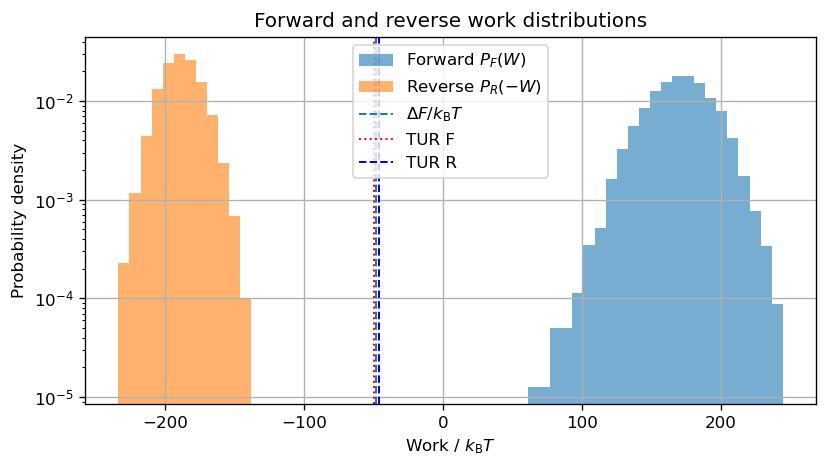

In [16]:

forward_work_dimensionless = W_fwd / kBT
negative_reverse_work_dimensionless = -W_rev / kBT

combined_work = np.concatenate([
    forward_work_dimensionless,
    negative_reverse_work_dimensionless,
])

work_min = np.min(combined_work)
work_max = np.max(combined_work)

if np.isclose(work_min, work_max):
    work_min -= 0.5
    work_max += 0.5

shared_bins = np.linspace(work_min, work_max, 61)

TUR_F = W_mean_fwd[-1] - cumulative_sig_f[-1]
TUR_R = -(W_mean_rev[-1] - cumulative_sig_r[-1])

plt.figure(figsize=(7, 4))
plt.hist(
    forward_work_dimensionless,
    bins=shared_bins,
    density=True,
    alpha=0.6,
    label=r"Forward $P_F(W)$",
)
plt.hist(
    negative_reverse_work_dimensionless,
    bins=shared_bins,
    density=True,
    alpha=0.6,
    label=r"Reverse $P_R(-W)$",
)

plt.axvline(
    result["DeltaF_kBT"],
    linestyle="--",
    linewidth=1.2,
    label=r"$\Delta F/k_{\rm B}T$",
)
plt.axvline(
    TUR_F,
    linestyle=":",
    linewidth=1.2,
    label="TUR F",
    color = 'red'
)
plt.axvline(
    TUR_R,
    linestyle="--",
    linewidth=1.2,
    label="TUR R",
    color = 'blue'
)

plt.yscale("log")
plt.xlabel(r"Work / $k_{\rm B}T$")
plt.ylabel("Probability density")
plt.legend()
plt.title("Forward and reverse work distributions")
plt.tight_layout()
plt.show()



## 18. Optional convergence checks

For publication-quality results, repeat the calculation while varying:

- the number of trajectories \(N\),
- the integration timestep \(dt\),
- the initial and final plateau durations,
- the polynomial basis used by the entropy-production estimator,
- the covariance ridge parameter.

A result should be regarded as converged only when the reported quantities are stable within their statistical uncertainty under these changes.


In [17]:

# Example lightweight convergence settings.
# Uncomment and adapt as needed.

# for N_test in [1_000, 5_000, 10_000]:
#     t_test, x_test, sigma_test = langevin_ensemble(
#         N=N_test,
#         a=a,
#         xscale=xscale,
#         mu=mu,
#         D=D,
#         dt=dt,
#         teq1=teq1,
#         ttrans=ttrans,
#         teq2=teq2,
#         seed=123,
#         reverse=False,
#     )
#     total_entropy = np.sum(sigma_test) * (t_test[1] - t_test[0])
#     print(f"N={N_test:6d}: total entropy estimate = {total_entropy:.6f}")


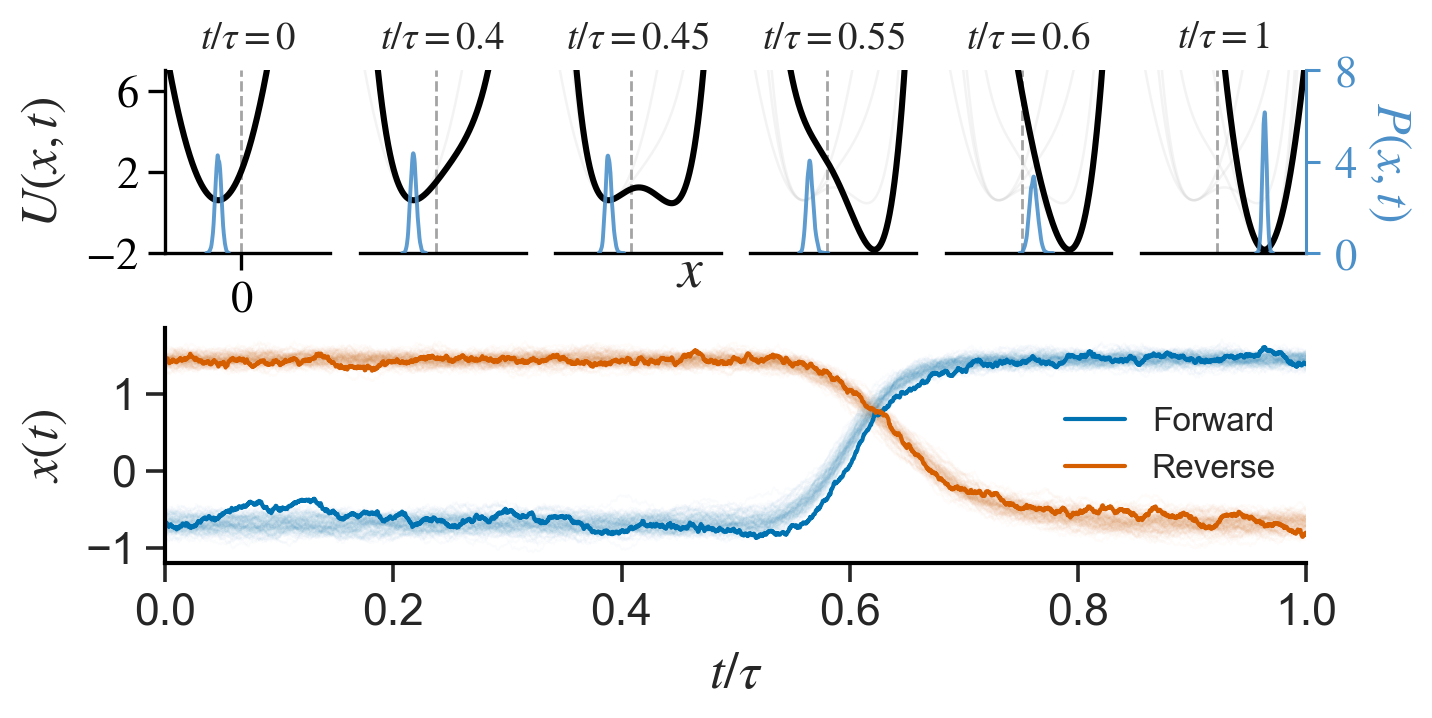

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator

%matplotlib inline

sns.set_style("white")

# ============================================================
# Plotting parameters
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",

    "font.size": 15,
    "axes.labelsize": 19,
    "axes.linewidth": 1.2,

    "xtick.labelsize": 16,
    "ytick.labelsize": 16,

    "legend.fontsize": 16,
    "legend.handlelength": 1.8,
    "legend.frameon": False,

    "mathtext.fontset": "stix",
    "mathtext.default": "it",

    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "figure.dpi": 200,
    "savefig.dpi": 600,
})

COLOR_FWD = "#0072B2"
COLOR_REV = "#D55E00"
COLOR_DIST = "#4C90C9"


# ============================================================
# Check that the simulations have already been run
# ============================================================

required_variables = [
    "t_arr",
    "t_arr_rev",
    "x_fwd",
    "x_rev",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise NameError(
        "Run the forward and reverse simulations before this "
        "plotting cell. Missing variables: "
        + ", ".join(missing_variables)
    )

t_arr = np.asarray(t_arr, dtype=float)
t_arr_rev = np.asarray(t_arr_rev, dtype=float)
x_fwd = np.asarray(x_fwd, dtype=float)
x_rev = np.asarray(x_rev, dtype=float)

if t_arr.ndim != 1:
    raise ValueError("t_arr must be one-dimensional.")

if t_arr_rev.ndim != 1:
    raise ValueError("t_arr_rev must be one-dimensional.")

if x_fwd.ndim != 2:
    raise ValueError(
        "x_fwd must have shape "
        "(number_of_trajectories, number_of_times)."
    )

if x_rev.ndim != 2:
    raise ValueError(
        "x_rev must have shape "
        "(number_of_trajectories, number_of_times)."
    )

if x_fwd.shape[1] != len(t_arr):
    raise ValueError(
        "The number of time points in x_fwd must match len(t_arr)."
    )

if x_rev.shape[1] != len(t_arr_rev):
    raise ValueError(
        "The number of time points in x_rev must match len(t_arr_rev)."
    )

if t_arr[-1] <= 0.0 or t_arr_rev[-1] <= 0.0:
    raise ValueError(
        "The final forward and reverse times must be positive."
    )


# ============================================================
# Potential definitions
# ============================================================

def U_doublewell(
    x,
    a=-1.0,
    xscale=1.0,
):
    """
    Asymmetric double-well potential.

    The rescaled coordinate y = x/xscale changes the horizontal
    separation of the wells while preserving the dimensionless
    energy profile.
    """
    if xscale <= 0.0:
        raise ValueError("xscale must be positive.")

    y = np.asarray(x, dtype=float) / xscale

    return (
        (y**2 - 1.0)**2
        + a * y**3
    )


def dUdx(
    x,
    a=-1.0,
    xscale=1.0,
):
    """First spatial derivative of the double-well potential."""
    if xscale <= 0.0:
        raise ValueError("xscale must be positive.")

    y = np.asarray(x, dtype=float) / xscale

    return (
        4.0 * y * (y**2 - 1.0)
        + 3.0 * a * y**2
    ) / xscale


def d2Udx2(
    x,
    a=-1.0,
    xscale=1.0,
):
    """Second spatial derivative of the double-well potential."""
    if xscale <= 0.0:
        raise ValueError("xscale must be positive.")

    y = np.asarray(x, dtype=float) / xscale

    return (
        12.0 * y**2
        - 4.0
        + 6.0 * a * y
    ) / xscale**2


def find_minima(
    a=-1.0,
    xscale=1.0,
):
    """
    Find the two nonzero stationary points analytically.

    The stationary-point equation in y=x/xscale is

        y (4 y^2 + 3 a y - 4) = 0.

    The two nonzero roots correspond to the left and right minima.
    """
    if xscale <= 0.0:
        raise ValueError("xscale must be positive.")

    discriminant = np.sqrt(
        9.0 * a**2 + 64.0
    )

    y_left = (
        -3.0 * a - discriminant
    ) / 8.0

    y_right = (
        -3.0 * a + discriminant
    ) / 8.0

    minima = xscale * np.array(
        [y_left, y_right],
        dtype=float,
    )

    minima.sort()

    curvatures = d2Udx2(
        minima,
        a=a,
        xscale=xscale,
    )

    if np.any(curvatures <= 0.0):
        raise ValueError(
            "Expected both nonzero stationary points to be minima, "
            f"but obtained curvatures {curvatures}."
        )

    return float(minima[0]), float(minima[1])


def prepare_potential(
    a=-1.0,
    xscale=1.0,
):
    """Precompute time-independent potential quantities."""
    xL, xR = find_minima(
        a=a,
        xscale=xscale,
    )

    UL0 = U_doublewell(
        xL,
        a=a,
        xscale=xscale,
    )

    UR0 = U_doublewell(
        xR,
        a=a,
        xscale=xscale,
    )

    kL = d2Udx2(
        xL,
        a=a,
        xscale=xscale,
    )

    kR = d2Udx2(
        xR,
        a=a,
        xscale=xscale,
    )

    return {
        "a": float(a),
        "xscale": float(xscale),
        "xL": float(xL),
        "xR": float(xR),
        "UL0": float(UL0),
        "UR0": float(UR0),
        "kL": float(kL),
        "kR": float(kR),
    }


def U_harmonic(
    x,
    x0,
    a=-1.0,
    xscale=1.0,
):
    """Harmonic approximation around the minimum x0."""
    U0 = U_doublewell(
        x0,
        a=a,
        xscale=xscale,
    )

    k = d2Udx2(
        x0,
        a=a,
        xscale=xscale,
    )

    if k <= 0.0:
        raise ValueError(
            f"x0={x0} is not a minimum because its curvature is {k}."
        )

    return (
        U0
        + 0.5
        * k
        * (np.asarray(x, dtype=float) - x0)**2
    )


# ============================================================
# Smooth interpolation protocol
# ============================================================

def smoothstep(u):
    """Cubic smoothstep on the interval [0,1]."""
    u = np.clip(
        np.asarray(u, dtype=float),
        0.0,
        1.0,
    )

    return u * u * (3.0 - 2.0 * u)


def U_time(
    x,
    t,
    a=-1.0,
    xscale=1.0,
    teq1=0.6,
    ttrans=0.8,
    teq2=0.6,
    potential=None,
):
    """
    Forward time-dependent potential.

    Protocol:
        left harmonic
        -> double well
        -> right harmonic.
    """
    del teq2

    if ttrans <= 0.0:
        raise ValueError("ttrans must be positive.")

    if potential is None:
        potential = prepare_potential(
            a=a,
            xscale=xscale,
        )

    x_array = np.asarray(
        x,
        dtype=float,
    )

    U_L = (
        potential["UL0"]
        + 0.5
        * potential["kL"]
        * (x_array - potential["xL"])**2
    )

    U_R = (
        potential["UR0"]
        + 0.5
        * potential["kR"]
        * (x_array - potential["xR"])**2
    )

    U_DW = U_doublewell(
        x_array,
        a=potential["a"],
        xscale=potential["xscale"],
    )

    # Initial equilibration plateau.
    if t <= teq1:
        return U_L

    # Final equilibration plateau.
    if t >= teq1 + ttrans:
        return U_R

    s = (t - teq1) / ttrans

    # First half of the ramp:
    # left harmonic -> double well.
    if s < 0.5:
        q = 2.0 * s

        beta = smoothstep(q)
        alpha = 1.0 - beta
        gamma = 0.0

    # Second half of the ramp:
    # double well -> right harmonic.
    else:
        q = 2.0 * s - 1.0

        gamma = smoothstep(q)
        alpha = 0.0
        beta = 1.0 - gamma

    return (
        alpha * U_L
        + beta * U_DW
        + gamma * U_R
    )


# ============================================================
# Parameters
# ============================================================

a = -1.0
xscale = 1.0

teq1 = 0.9
ttrans = 1.2
teq2 = 0.9

tau = (
    teq1
    + ttrans
    + teq2
)

potential = prepare_potential(
    a=a,
    xscale=xscale,
)

if not np.isclose(
    t_arr[-1],
    tau,
    rtol=1e-8,
    atol=1e-10,
):
    print(
        "Warning: t_arr[-1] differs from the plotting "
        f"protocol duration tau. t_arr[-1]={t_arr[-1]}, "
        f"tau={tau}."
    )

# Original spatial plotting range.
x = np.linspace(
    -2.3,
    2.7,
    900,
)

snapshot_fracs = np.array([
    0.0,
    0.4,
    0.45,
    0.55,
    0.6,
    1.0,
])

snapshot_times = (
    snapshot_fracs * tau
)


# ============================================================
# Figure layout
# ============================================================

fig = plt.figure(
    figsize=(7, 3.2),
)

outer = fig.add_gridspec(
    2,
    1,
    height_ratios=[1.05, 1.35],
    hspace=0.36,
)

gs_pot = outer[0].subgridspec(
    1,
    len(snapshot_fracs),
    wspace=0.18,
)

ax_pots = [
    fig.add_subplot(
        gs_pot[0, i]
    )
    for i in range(
        len(snapshot_fracs)
    )
]

ax_traj = fig.add_subplot(
    outer[1]
)


# ============================================================
# A. Potential snapshots and empirical forward distributions
# ============================================================

dist_axes = []

# Actual probability-density scale.
ymax_dist = 8.0

for k, (ax, frac, t_snap) in enumerate(
    zip(
        ax_pots,
        snapshot_fracs,
        snapshot_times,
    )
):
    U_now = U_time(
        x,
        t_snap,
        a=a,
        xscale=xscale,
        teq1=teq1,
        ttrans=ttrans,
        teq2=teq2,
        potential=potential,
    )

    idx_f = int(
        np.argmin(
            np.abs(
                t_arr - t_snap
            )
        )
    )

    samples = x_fwd[
        :,
        idx_f,
    ]

    samples = samples[
        np.isfinite(samples)
    ]

    if samples.size < 2:
        raise ValueError(
            f"Too few finite samples at time index {idx_f}."
        )

    ax_dist = ax.twinx()
    dist_axes.append(ax_dist)

    ax_dist.set_ylim(
        0.0,
        ymax_dist,
    )

    for spine in [
        "top",
        "left",
        "bottom",
    ]:
        ax_dist.spines[
            spine
        ].set_visible(False)

    ax_dist.spines[
        "right"
    ].set_linewidth(1.1)

    ax_dist.spines[
        "right"
    ].set_color(COLOR_DIST)

    if k == len(snapshot_fracs) - 1:
        ax_dist.spines[
            "right"
        ].set_visible(True)

        ax_dist.set_yticks([
            0.0,
            0.5 * ymax_dist,
            ymax_dist,
        ])

        ax_dist.set_yticklabels([
            r"$0$",
            rf"${0.5 * ymax_dist:g}$",
            rf"${ymax_dist:g}$",
        ], fontsize=16)

        ax_dist.tick_params(
            axis="y",
            which="major",
            direction="out",
            length=5,
            width=1.1,
            colors=COLOR_DIST,
            right=True,
            left=False,
            labelright=True,
            labelleft=False,
            pad=5,
        )

        ax_dist.set_ylabel(
            r"$P(x,t)$",
            fontsize=18,
            color=COLOR_DIST,
            rotation=270,
            labelpad=20,
        )

    else:
        ax_dist.set_yticks([])

        ax_dist.spines[
            "right"
        ].set_visible(False)

        ax_dist.tick_params(
            axis="y",
            right=False,
            left=False,
            labelright=False,
            labelleft=False,
        )

    # Actual KDE probability density; no peak normalization.
    sns.kdeplot(
        x=samples,
        ax=ax_dist,
        color=COLOR_DIST,
        lw=1.4,
        alpha=0.9,
        bw_adjust=0.9,
        clip=(-2.7, 2.7),
        cut=0,
        zorder=1,
    )

    ax_dist.set_ylim(
        0.0,
        ymax_dist,
    )

    # Previous potentials in the pale background.
    for j in range(k):
        U_prev = U_time(
            x,
            snapshot_times[j],
            a=a,
            xscale=xscale,
            teq1=teq1,
            ttrans=ttrans,
            teq2=teq2,
            potential=potential,
        )

        ax.plot(
            x,
            U_prev,
            color="0.75",
            linewidth=0.9,
            alpha=0.18,
        )

    ax.plot(
        x,
        U_now,
        color="black",
        linewidth=2.2,
    )

    ax.axvline(
        0.0,
        color="0.35",
        linewidth=1.0,
        linestyle="--",
        alpha=0.55,
        zorder=0,
    )

    ax.text(
        0.5,
        1.08,
        rf"$t/\tau={frac:.2g}$",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=14,
    )

    ax.set_xlim(
        x[0],
        x[-1],
    )

    ax.set_ylim(
        -2.0,
        7.0,
    )

    ax.set_xlabel("")

    if k == 0:
        ax.set_xticks([
            0.0,
        ])

        ax.set_xticklabels([
            r"$0$",
        ], fontsize=16)

    else:
        ax.set_xticks([])

    if k == 0:
        ax.set_ylabel(
            r"$U(x,t)$",
            fontsize=19,
            labelpad=6,
        )

        ax.set_yticks([
            -2,
            2,
            6,
        ])

        ax.set_yticklabels([
            r"$-2$",
            r"$2$",
            r"$6$",
        ], fontsize=16)

        ax.tick_params(
            axis="y",
            which="major",
            direction="out",
            length=6,
            width=1.2,
            colors="black",
            left=True,
            right=False,
        )

        ax.spines[
            "left"
        ].set_visible(True)

        ax.spines[
            "left"
        ].set_linewidth(1.2)

        ax.spines[
            "left"
        ].set_color("black")

    else:
        ax.set_yticks([])

        ax.spines[
            "left"
        ].set_visible(False)

    ax.tick_params(
        axis="x",
        which="major",
        direction="out",
        length=6,
        width=1.2,
        colors="black",
        bottom=True,
        top=False,
    )

    for spine in [
        "top",
        "right",
    ]:
        ax.spines[
            spine
        ].set_visible(False)

    ax.spines[
        "bottom"
    ].set_linewidth(1.2)

    ax.spines[
        "bottom"
    ].set_color("black")


fig.text(
    0.50,
    0.565,
    r"$x$",
    ha="center",
    va="center",
    fontsize=20,
)


# ============================================================
# B. Trajectories
# ============================================================

tt_f = (
    t_arr / t_arr[-1]
)

tt_r = (
    t_arr_rev / t_arr_rev[-1]
)

number_of_background_trajectories = min(
    100,
    x_fwd.shape[0],
    x_rev.shape[0],
)

for i in range(
    number_of_background_trajectories
):
    ax_traj.plot(
        tt_f,
        x_fwd[i],
        color=COLOR_FWD,
        linewidth=0.6,
        alpha=0.025,
    )

    ax_traj.plot(
        tt_r,
        x_rev[i],
        color=COLOR_REV,
        linewidth=0.6,
        alpha=0.025,
    )

example_idx_f = 0
example_idx_r = 0

ax_traj.plot(
    tt_f,
    x_fwd[example_idx_f],
    color=COLOR_FWD,
    linewidth=1.5,
    label="Forward",
)

ax_traj.plot(
    tt_r,
    x_rev[example_idx_r],
    color=COLOR_REV,
    linewidth=1.5,
    label="Reverse",
)

ax_traj.set_xlabel(
    r"$t/\tau$",
    fontsize=19,
    labelpad=6,
)

ax_traj.set_ylabel(
    r"$x(t)$",
    fontsize=19,
    labelpad=6,
)

ax_traj.set_xlim(
    0.0,
    1.0,
)

ax_traj.xaxis.set_minor_locator(
    AutoMinorLocator(2)
)

ax_traj.yaxis.set_minor_locator(
    AutoMinorLocator(2)
)

ax_traj.spines[
    "top"
].set_visible(False)

ax_traj.spines[
    "right"
].set_visible(False)

ax_traj.spines[
    "bottom"
].set_linewidth(1.5)

ax_traj.spines[
    "bottom"
].set_color("black")

ax_traj.spines[
    "left"
].set_linewidth(1.5)

ax_traj.spines[
    "left"
].set_color("black")

ax_traj.tick_params(
    axis="x",
    which="major",
    direction="out",
    length=7,
    width=1.3,
    bottom=True,
    top=False,
    labelsize=16,
)

ax_traj.tick_params(
    axis="y",
    which="major",
    direction="out",
    length=7,
    width=1.3,
    left=True,
    right=False,
    labelsize=16,
)

ax_traj.tick_params(
    axis="x",
    which="minor",
    direction="out",
    length=4,
    width=1.0,
)

ax_traj.tick_params(
    axis="y",
    which="minor",
    direction="out",
    length=4,
    width=1.0,
)

ax_traj.grid(False)

ax_traj.legend(
    frameon=False,
    fontsize=12,
    loc="center right",
)


# ============================================================
# Save and show
# ============================================================

fig.subplots_adjust(
    right=0.94,
)

plt.savefig(
    "protocol_plot.pdf",
    bbox_inches="tight",
    transparent=True,
    pad_inches=0.08,
)

plt.show()

In [19]:
!pwd

/Users/sreekanthkmanikandan/Documents/FreeEnergyInference/DoubleWell


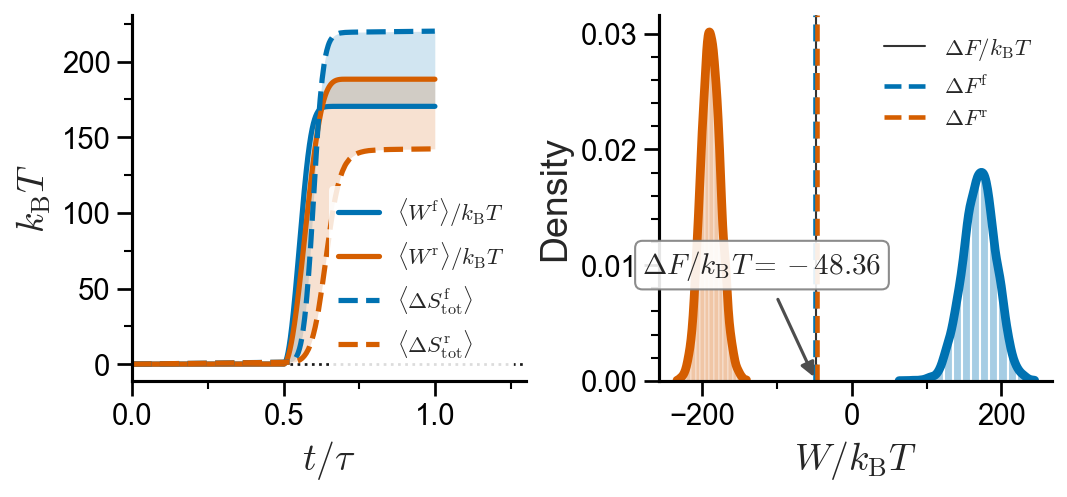

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator
import logging

fonttools_logger = logging.getLogger("fontTools")
fonttools_logger.setLevel(logging.ERROR)
fonttools_logger.propagate = False
fonttools_logger.handlers.clear()
fonttools_logger.addHandler(logging.NullHandler())


# ------------------------------------------------------------
# Style
# ------------------------------------------------------------
sns.set_style("white")

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.linewidth": 1.4,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 11,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "mathtext.fontset": "cm",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

COLOR_FWD = "#0072B2"
COLOR_REV = "#D55E00"
COLOR_ENT_F = "#009E73"
COLOR_ENT_R = "#CC79A7"
res = result
# ------------------------------------------------------------
# Derived quantities
# ------------------------------------------------------------
W_mean_fwd = W_cum_fwd.mean(axis=0) / D
W_mean_rev = W_cum_rev.mean(axis=0) / D

cum_sig_f = np.cumsum(sig_f * dt)
cum_sig_r = np.cumsum(sig_r * dt)

tur_f = W_mean_fwd[-1] - cum_sig_f[-1]
tur_r = -(W_mean_rev[-1] - cum_sig_r[-1])

tt_f = t_arr / t_arr[-1]
tt_r = t_arr_rev / t_arr_rev[-1]

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, (ax_work, ax_dist) = plt.subplots(
    1, 2, figsize=(7, 3.2), constrained_layout=True
)

# ============================================================
# A. Mean cumulative work and entropy estimate
# ============================================================
ax_work.axhline(0, color="black", lw=1.3, ls=":", alpha=0.9)

ax_work.plot(
    tt_f, W_mean_fwd,
    color=COLOR_FWD,
    lw=2.5,
    label=r"$\langle W^{\rm f}\rangle/k_{\rm B}T$",
)

ax_work.plot(
    tt_r, W_mean_rev,
    color=COLOR_REV,
    lw=2.5,
    label=r"$\langle W^{\rm r}\rangle/k_{\rm B}T$",
)

ax_work.plot(
    tt_f[:-1], cum_sig_f,
    "--",
    color=COLOR_FWD,
    lw=2.5,
    label=r"$\langle \Delta S_{\mathrm{tot}}^{\rm f}\rangle$",
)

ax_work.plot(
    tt_r[:-1], cum_sig_r,
    "--",
    color=COLOR_REV,
    lw=2.5,
    label=r"$\langle \Delta S_{\mathrm{tot}}^{\rm r}\rangle$",
)

ax_work.fill_between(
    tt_f[:-1],
    cum_sig_f,
    W_mean_fwd[:-1],
    color=COLOR_FWD,
    alpha=0.18,
    linewidth=0,
)

ax_work.fill_between(
    tt_r[:-1],
    W_mean_rev[:-1],
    cum_sig_r,
    color=COLOR_REV,
    alpha=0.18,
    linewidth=0,
)

ax_work.set_xlabel(r"$t/\tau$")
ax_work.set_ylabel(r"$k_{\rm B}T$")
ax_work.set_xlim(0, 1.3)
ax_work.grid(False)

ax_work.legend(
    frameon=True,
    facecolor="white",
    edgecolor="none",
    framealpha=0.85,
    loc="best",
)

# ============================================================
# B. Work distributions
# ============================================================
sns.histplot(
    W_fwd / D,
    bins=15,
    stat="density",
    color=COLOR_FWD,
    alpha=0.35,
    kde=True,
    line_kws={"lw": 4.2},
    ax=ax_dist,
)

sns.histplot(
    -W_rev / D,
    bins=15,
    stat="density",
    color=COLOR_REV,
    alpha=0.35,
    kde=True,
    line_kws={"lw": 4.2},
    ax=ax_dist,
)

ax_dist.axvline(
    res["DeltaF_kBT"],
    color="black",
    ls="-",
    lw=1.0,
    label=r"$\Delta F/k_{\rm B}T$",
    alpha = 0.8
)

ax_dist.axvline(
    tur_f,
    color=COLOR_FWD,
    ls="--",
    lw=2.2,
    label=r"$\Delta F^{\rm f}$",
)

ax_dist.axvline(
    tur_r,
    color=COLOR_REV,
    ls="--",
    lw=2.2,
    label=r"$\Delta F^{\rm r}$",
)

ax_dist.set_xlabel(r"$W/k_{\rm B}T$")
ax_dist.set_ylabel("Density")
#ax_dist.set_yscale("log")
ax_dist.grid(False)



ax_dist.annotate(
    rf"$\Delta F/k_\mathrm{{B}}T = {res['DeltaF_kBT']:.2f}$",
    xy=(res["DeltaF_kBT"], 1e-5),
    xytext=(-120, 1e-2),
    fontsize=14,
    ha="center",
    va="center",
    bbox=dict(
        facecolor="white",
        alpha=0.9,
        edgecolor="0.5",
        boxstyle="round,pad=0.25",
    ),
    arrowprops=dict(
        arrowstyle="-|>",
        color="0.3",
        lw=1.5,
        shrinkA=5,
        shrinkB=2,
    ),
)

ax_dist.legend(
    loc="upper right",
    frameon=True,
    facecolor="white",
    framealpha=0.85,
    edgecolor="none",
)

# ------------------------------------------------------------
# Final tick/spine cleanup
# ------------------------------------------------------------
for ax in (ax_work, ax_dist):

    ax.minorticks_on()

    ax.xaxis.set_minor_locator(AutoMinorLocator(2))

    if ax is ax_work:
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=7,
        width=1.3,
        bottom=True,
        left=True,
        top=False,
        right=False,
        colors="black",
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="out",
        length=4,
        width=1.0,
        bottom=True,
        left=True,
        top=False,
        right=False,
        colors="black",
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["bottom"].set_visible(True)
    ax.spines["left"].set_visible(True)

    ax.spines["bottom"].set_linewidth(1.5)
    ax.spines["left"].set_linewidth(1.5)

    ax.spines["bottom"].set_color("black")
    ax.spines["left"].set_color("black")

plt.savefig(
    "work_entropy.pdf",
    bbox_inches="tight",
    transparent=True,
    pad_inches=0.08,
)

plt.show()